In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
# Carpeta donde están los CSV
carpeta_csv = r"C:\Tiago\0_Status_Outlook_Bulletin\waterbalance\Modelo_balance_python\Python\9_Validacion_ESP_jupyter_notebook\Resultados\01_Tablas_de_resultados"

# Buscar todos los csv
archivos = glob.glob(os.path.join(carpeta_csv, "*.csv"))

In [33]:
resultados = []
for archivo in archivos:
    df = pd.read_csv(archivo)

    # filtrar lead 1
    df = df[df["lead"] == 1].copy()

    # asegurar numéricos
    df["ens_prom"] = pd.to_numeric(df["ens_prom"], errors="coerce")
    df["QC_hist"] = pd.to_numeric(df["QC_hist"], errors="coerce")

    # bias relativo (recomendado)
    df["bias"] = (df["ens_prom"] - df["QC_hist"])/df["ens_prom"]

    # promedio por fecha (dentro de cada cuenca/archivo)
    bias_fecha = df.groupby("fecha_pronostico")["bias"].mean()
    #print(bias_fecha.head)

    resultados.append(bias_fecha)


In [42]:
# unir todas las cuencas
df_bias = pd.concat(resultados, axis=1)

# promedio entre cuencas (cada columna = una cuenca)
bias_promedio = df_bias.mean(axis=1)

# ordenar por fecha
bias_promedio.index = pd.to_datetime(bias_promedio.index)
bias_promedio = bias_promedio.sort_index()

# acumulado temporal
bias_acumulado = bias_promedio.cumsum()
print(bias_acumulado)

fecha_pronostico
1985-02-15     0.768562
1985-03-15     0.502418
1985-04-15     1.015147
1985-05-15     1.006176
1985-06-15     0.055462
                ...    
2025-03-15   -50.565691
2025-04-15   -49.808202
2025-05-15   -50.057367
2025-06-15   -49.499683
2025-07-15   -49.300827
Length: 486, dtype: float64


In [43]:
ruta_enso_ano = r"C:\Tiago\0_Status_Outlook_Bulletin\waterbalance\Modelo_balance_python\Python\9_Validacion_ESP_jupyter_notebook\Datos_entrada\nina34_anom.csv"

df_enso = pd.read_csv(ruta_enso_ano)

df_enso.columns = df_enso.columns.str.strip()

# parsear fecha
df_enso["Date"] = pd.to_datetime(df_enso["Date"])

# asegurar numérico
df_enso["Nino Anom 3.4"] = pd.to_numeric(df_enso["Nino Anom 3.4"], errors="coerce")

df_enso = df_enso.set_index("Date").sort_index()


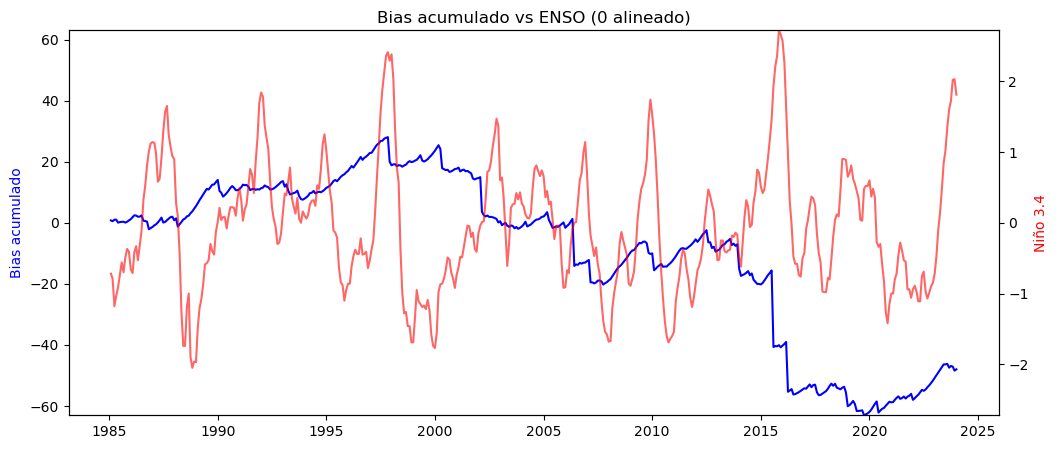

In [55]:
enso = df_enso["Nino Anom 3.4"].resample("MS").mean()
enso.name = "enso"

bias_acumulado = bias_acumulado.resample("MS").mean()
bias_acumulado.name = "bias"
df_plot = pd.concat([bias_acumulado, enso], axis=1).dropna()

fig, ax1 = plt.subplots(figsize=(12, 5))

# series
ax1.plot(df_plot.index, df_plot["bias"], color="blue")
ax1.set_ylabel("Bias acumulado", color="blue")

ax2 = ax1.twinx()
ax2.plot(df_plot.index, df_plot["enso"], color="red", alpha=0.6)
ax2.set_ylabel("Niño 3.4", color="red")

# --- ALINEAR CERO ---
def symmetric_limits(series):
    m = np.nanmax(np.abs(series))
    return -m, m

ax1.set_ylim(symmetric_limits(df_plot["bias"]))
ax2.set_ylim(symmetric_limits(df_plot["enso"]))

plt.savefig(r"C:\Tiago\0_Status_Outlook_Bulletin\waterbalance\Modelo_balance_python\Python\Doc_validacion\p_bias_acumuldo_enso.png", dpi=300)
plt.title("Bias acumulado vs ENSO (0 alineado)")
plt.show()